<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 GLMM: GLM + LMM = GLMM

### Table of contents
1. Introduction
2. Reading the data
3. Data Inspection
4. Data summary
5. Data Visualisation
6. Model Diagnostics
7. Diagnostics





<div class="alert alert-block alert-info" style="margin-top: 20px">
    
## 1. Introduction:
These data come from the book “Mixed effects models with extensions in Ecology with R” from Zuur et Al. It uses a dataset where species richness, as the number of species, was recorded on different beaches, 5 samples where taken from each beach and its marco-fauna, abiotic variables and NAP (nieuw Amsterdams peil). Variables used.

* Richness: number of different species.
* NAP: Hight of Sampling station.
* Beach: Beach ID.
* Exposure: classification based on, wave action, surf zone, slope, grain size and depth of anaerobic layer.

## Generalized Linear Mixed Model (GLMM) Analysis using the RIKZ Dataset

### Step 1: Load Required Packages

####  Install packages if necessary


In [39]:
# install.packages("ggplot2")
# install.packages("lme4")
# install.packages("car")
# install.packages("lattice")
# install.packages("DHARMa")

# install.packages("googledrive")

In [ ]:
library(googledrive)
drive_auth()
tmp <- tempfile(fileext = ".txt")
drive_download(
  "RIKZ.txt",
  path = tmp,
  overwrite = TRUE
)

In [101]:
library(ggplot2)
library(lme4)
library(car)
library(lattice)
library(DHARMa)

## 2. Reading the data:

### Step 2: Import the Dataset

In [102]:
# Read the downloaded file:
# Read the RIKZ dataset
Rikz <- read.delim("RIKZ.txt")

# Display the first few observations
head(Rikz)

,Sample,Richness,Exposure,NAP,Beach
,<int>,<int>,<int>,<dbl>,<int>
1,1,11,10,0.045,1
2,2,10,10,-1.036,1
3,3,13,10,-1.336,1
4,4,11,10,0.616,1
5,5,10,10,-0.684,1
6,6,8,8,1.190,2


## 3. Data Inspection:
We first look at the structure of the data to check data types.

In [103]:
# Display the structure of the dataset
str(Rikz)

'data.frame':	45 obs. of  5 variables:
 $ Sample  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Richness: int  11 10 13 11 10 8 9 8 19 17 ...
 $ Exposure: int  10 10 10 10 10 8 8 8 8 8 ...
 $ NAP     : num  0.045 -1.036 -1.336 0.616 -0.684 ...
 $ Beach   : int  1 1 1 1 1 2 2 2 2 2 ...


We note that beaches and exposure are factors but they are read as numeric. The book suggested furthermore to make exposure a two level factor with levels 11 and 10 by making level 8 a 10.

### Step 3: Create Factor Variables
__Convert Beach into a Factor__

In [104]:
Rikz$Beaches <- factor(
  Rikz$Beach,
  labels = c(
    "beach1","beach2","beach3",
    "beach4","beach5","beach6",
    "beach7","beach8","beach9"
  )
)

__Recode Exposure Variable__

Exposure value 8 is recoded as 10.

In [105]:
Rikz$Expos <- Rikz$Exposure

Rikz$Expos[Rikz$Expos == 8] <- 10

Rikz$Expos <- factor(Rikz$Expos, levels = c(10,11))

### Step 4: Examine the Dataset

In [106]:
# Display structure
str(Rikz)

'data.frame':	45 obs. of  7 variables:
 $ Sample  : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Richness: int  11 10 13 11 10 8 9 8 19 17 ...
 $ Exposure: int  10 10 10 10 10 8 8 8 8 8 ...
 $ NAP     : num  0.045 -1.036 -1.336 0.616 -0.684 ...
 $ Beach   : int  1 1 1 1 1 2 2 2 2 2 ...
 $ Beaches : Factor w/ 9 levels "beach1","beach2",..: 1 1 1 1 1 2 2 2 2 2 ...
 $ Expos   : Factor w/ 2 levels "10","11": 1 1 1 1 1 1 1 1 1 1 ...


The data is now ready for analysis.

## 4. Data Summary:

In [107]:
# Display summary statistics
summary(Rikz)

     Sample      Richness         Exposure          NAP              Beach  
 Min.   : 1   Min.   : 0.000   Min.   : 8.00   Min.   :-1.3360   Min.   :1  
 1st Qu.:12   1st Qu.: 3.000   1st Qu.:10.00   1st Qu.:-0.3750   1st Qu.:3  
 Median :23   Median : 4.000   Median :10.00   Median : 0.1670   Median :5  
 Mean   :23   Mean   : 5.689   Mean   :10.22   Mean   : 0.3477   Mean   :5  
 3rd Qu.:34   3rd Qu.: 8.000   3rd Qu.:11.00   3rd Qu.: 1.1170   3rd Qu.:7  
 Max.   :45   Max.   :22.000   Max.   :11.00   Max.   : 2.2550   Max.   :9  
                                                                            
    Beaches   Expos  
 beach1 : 5   10:25  
 beach2 : 5   11:20  
 beach3 : 5          
 beach4 : 5          
 beach5 : 5          
 beach6 : 5          
 (Other):15          

Numerical data looks fine there is an relatively high value for Richness compare to the mean. But these are counts so a Poisson distribution is expected.

## 5. Data Visualisation:
we first plot the Richness against NAP for the different beaches.

### Step 5: Scatter Plot with Regression Lines

In [108]:
library(ggplot2)
p <- ggplot(Rikz,
            aes( x = NAP, y = Richness, colour = Beaches))

__Plot by Beach__

`geom_smooth()` using formula = 'y ~ x'


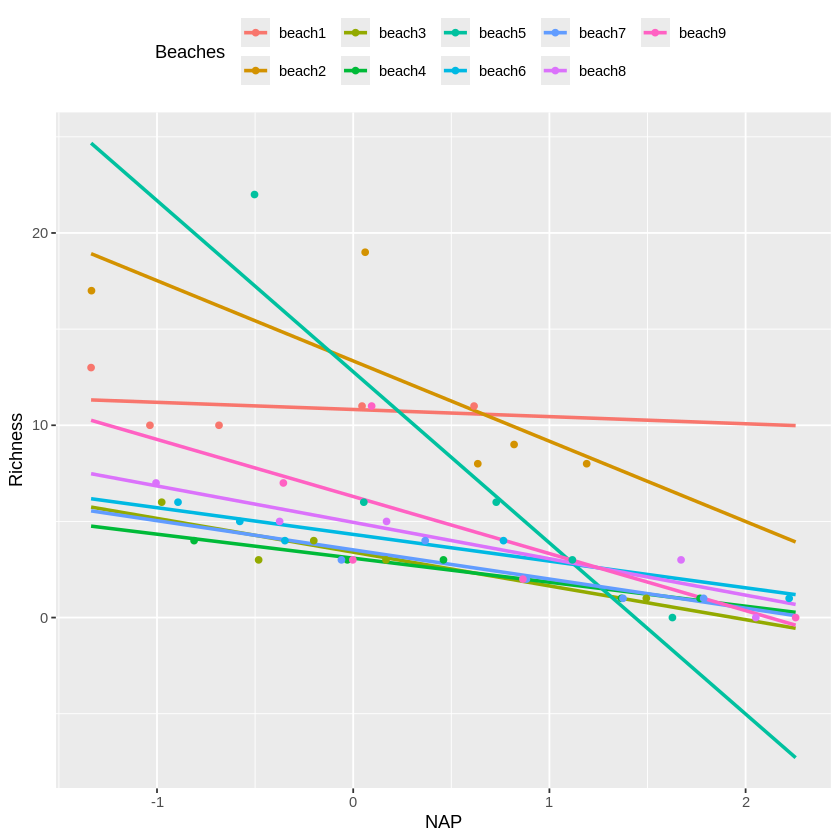

In [109]:
p +
  geom_smooth(
    method = "lm",
    size = 1,
    se = FALSE,
    fullrange = TRUE
  ) +
  geom_point() +
  theme(
    legend.position = "top"
  )

We see quite a diversity of slopes for the different beaches. We can add the exposure times into the plot.

__Separate Regression Lines by Exposure and Beach__

`geom_smooth()` using formula = 'y ~ x'


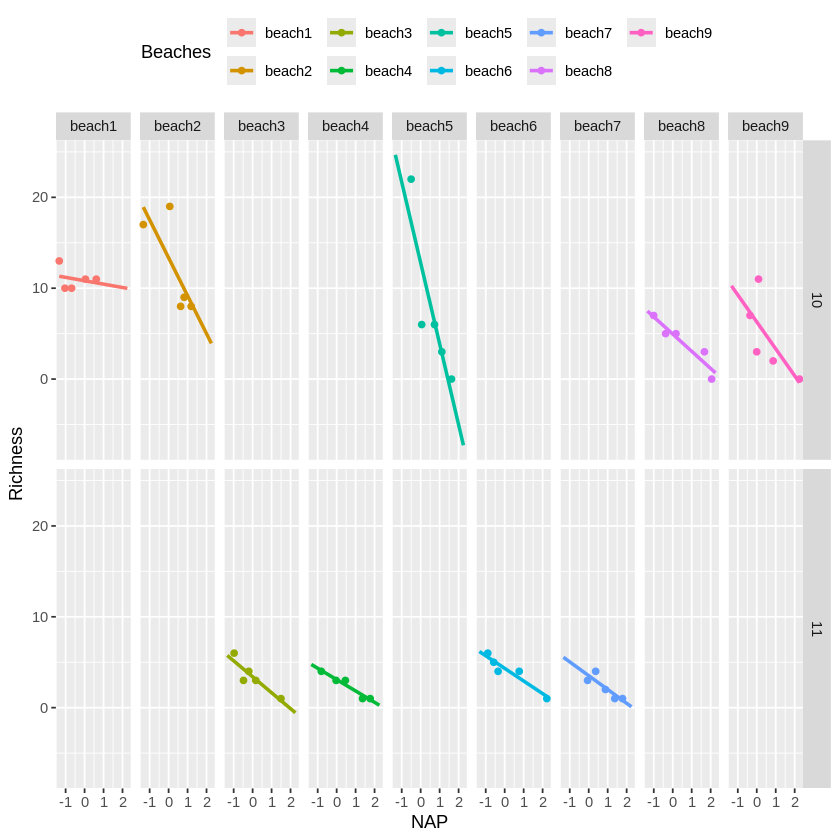

In [110]:
p +
  stat_smooth(
    method = "lm",
    size = 1,
    se = FALSE,
    fullrange = TRUE
  ) +
  geom_point() +
  facet_grid(
    Expos ~ Beaches
  ) +
  theme(
    legend.position = "top"
  )

This plot shows some design properties of our experimental design; Beaches are nested in Expos, levels 10 and 11, as every beach has only one of the two “treatments”. This makes sense because Expos is a beach property, it cannot have both properties at ones.



**Assignment**

Analyse this data a nested mixed model. Because there is only 1 level of nesting you do not need to code this explicitly. Use model Richness ~ NAP + (NAP|Beaches) to start with

First analyse the data using a normal linear model (lmer) and then a poisson glm version (glmer). This last methods has conversion problems. Use the result from the lmer analysis to make it work.

### Step 6: Fit Linear Mixed-Effects Models

__Model 1: Random Intercept and Random Slope__

In [111]:
library(lme4)

Model1 <- lmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (NAP | Expos:Beaches),
  data = Rikz
)

__Model 2: Random Slope Only__

In [112]:
Model2 <- lmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (0 + NAP | Expos:Beaches),
  data = Rikz
)

boundary (singular) fit: see help('isSingular')



__Model 3: Random Intercept Only__

In [113]:
Model3 <- lmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (1 | Expos:Beaches),
  data = Rikz
)

Model2 had singularity issues.

### Step 7: Compare Linear Mixed Models
__Akaike Information Criterion (AIC)__

In [114]:
AIC(Model1, Model2, Model3)

,df,AIC
,<dbl>,<dbl>
Model1,8,237.1331
Model2,6,240.5329
Model3,6,236.4925


model 3 has the lowest AIC . Next we implement the loglikelhood test.

__Likelihood Ratio Tests__

In [115]:
anova(Model1, Model2)

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model2,6,245.0875,255.9274,-116.5437,233.0875,NA,NA,NA
Model1,8,243.2210,257.6743,-113.6105,227.2210,5.866419,2,0.05322595


In [116]:
anova(Model1, Model3)

refitting model(s) with ML (instead of REML)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model3,6,242.1135,252.9535,-115.0568,230.1135,NA,NA,NA
Model1,8,243.2210,257.6743,-113.6105,227.2210,2.892462,2,0.2354561


Again model 3 is preferred.

## 6. Model Diagnostics:

### Step 8: Diagnostic Plots
__Residual Plot__

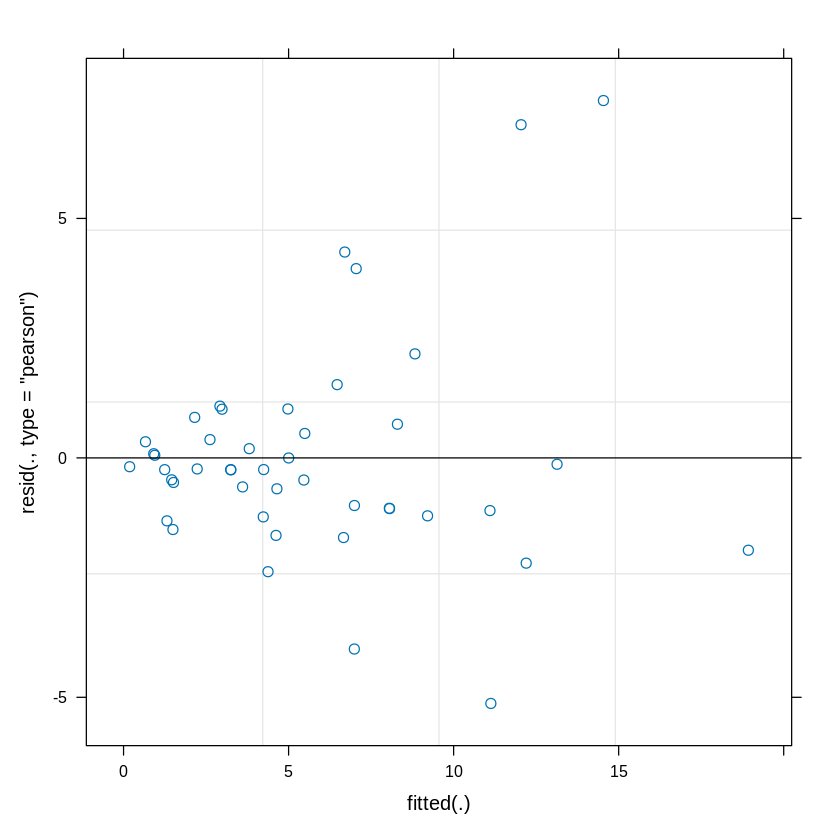

In [117]:
plot(Model1)

We observe some heteroscedastic maybe better do a glmm?

__Normal Q-Q Plot__

[1] 22  9

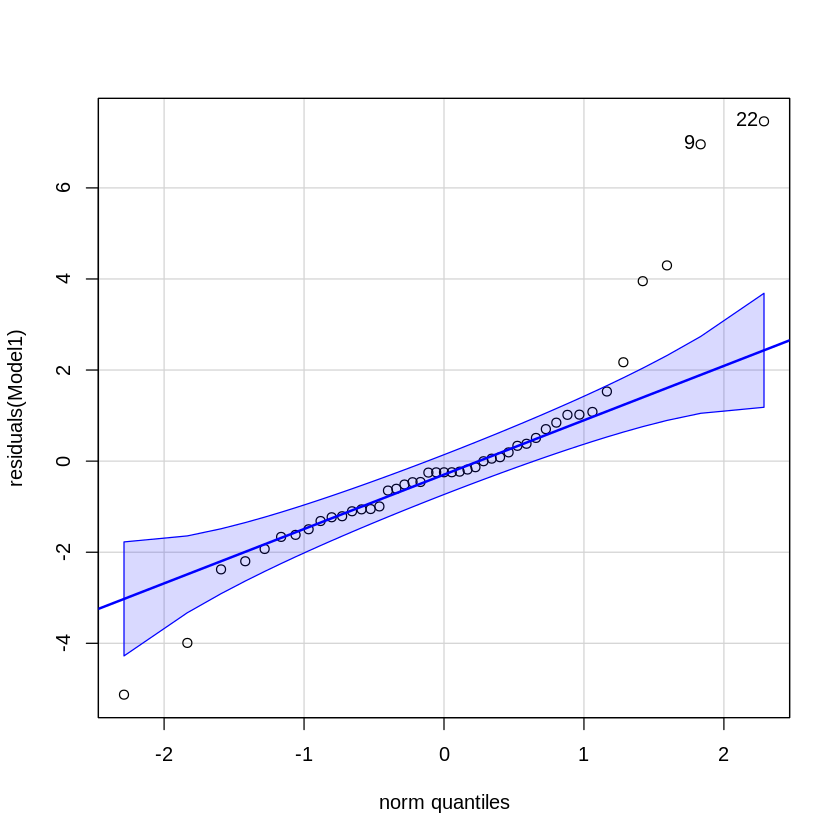

In [118]:
library(car)

qqPlot(residuals(Model1))

__Simulated Residual Diagnostics__

Strong sign of a poisson distribution, longer tail to the right.

More advanced diagnostic methods:

Object of Class DHARMa with simulated residuals based on 250 simulations with refit = FALSE . See ?DHARMa::simulateResiduals for help. 
 
Scaled residual values: 0.792 0.18 0.38 0.948 0.284 0.628 0.556 0.276 1 0.6 0.608 0.476 0.516 0.316 0.496 0.552 0.48 0.54 0.5 0.432 ...

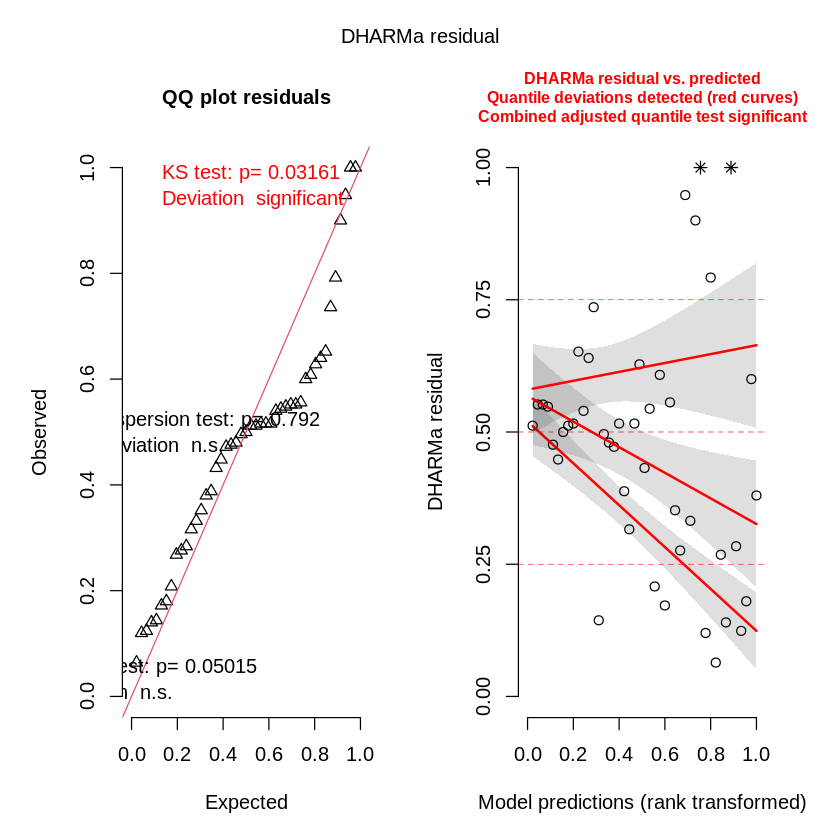

In [119]:
# simulateResiduals(Model3, plot = TRUE)

DHARMa::simulateResiduals(Model3, plot = T)

I think this drives the message home. Note that the KS test did not indicate deviation from normality (since it compares to a uniform distribution, but indirectly reflects normality). Also, the residuals vs. predicted plot shows signs of heteroscedasticity

Next a glmm:

### Step 9: Fit Generalized Linear Mixed Models (Poisson)
__Model 1g: Random Intercept and Random Slope__

In [120]:
Model1g <- glmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (NAP | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

__Model 2g: Random Slope Only__

In [121]:
Model2g <- glmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (0 + NAP | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

__Model 3g: Random Intercept Only__

In [122]:
Model3g <- glmer(
  Richness ~ Expos + NAP + NAP:Expos +
    (1 | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

### Step 10: Compare Poisson GLMMs
__AIC__

In [123]:
AIC(Model1g, Model2g, Model3g)

,df,AIC
,<dbl>,<dbl>
Model1g,7,213.1141
Model2g,5,219.4121
Model3g,5,215.4184


Model 1g has the lowest AIC . Next we implement the loglikelhood test.

__Likelihood Ratio Tests__

In [124]:
anova(Model1g, Model2g)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model2g,5,219.4121,228.4455,-104.70607,209.4121,NA,NA,NA
Model1g,7,213.1141,225.7608,-99.55707,199.1141,10.298,2,0.005805198


In [125]:
anova(Model1g, Model3g)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model3g,5,215.4184,224.4517,-102.70919,205.4184,NA,NA,NA
Model1g,7,213.1141,225.7608,-99.55707,199.1141,6.304244,2,0.04276129


A really closed finish between Model 1g and 3g. Here we need to choose. I proceed with model 1g because it also contains information on if the random variable affects slopes.

## 7. Diagnostics:

### Step 11: Model Diagnostics
__Residual Plot__

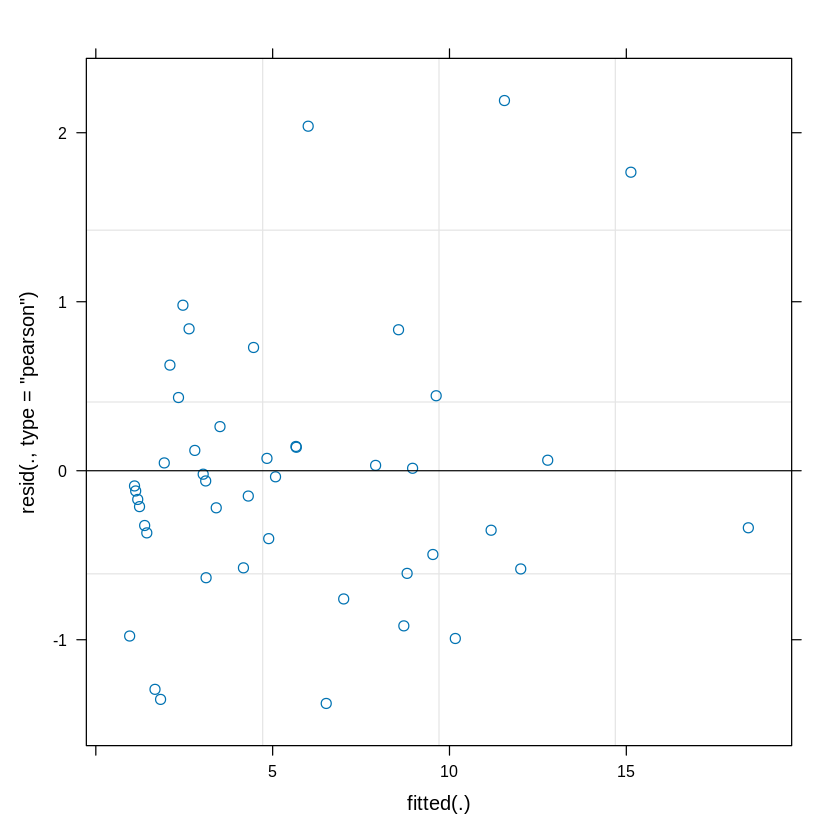

In [126]:
plot(Model1g)

Much better. Next test if the residuals are distributed Gaussian.

__Q-Q Plot__

[1]  9 42

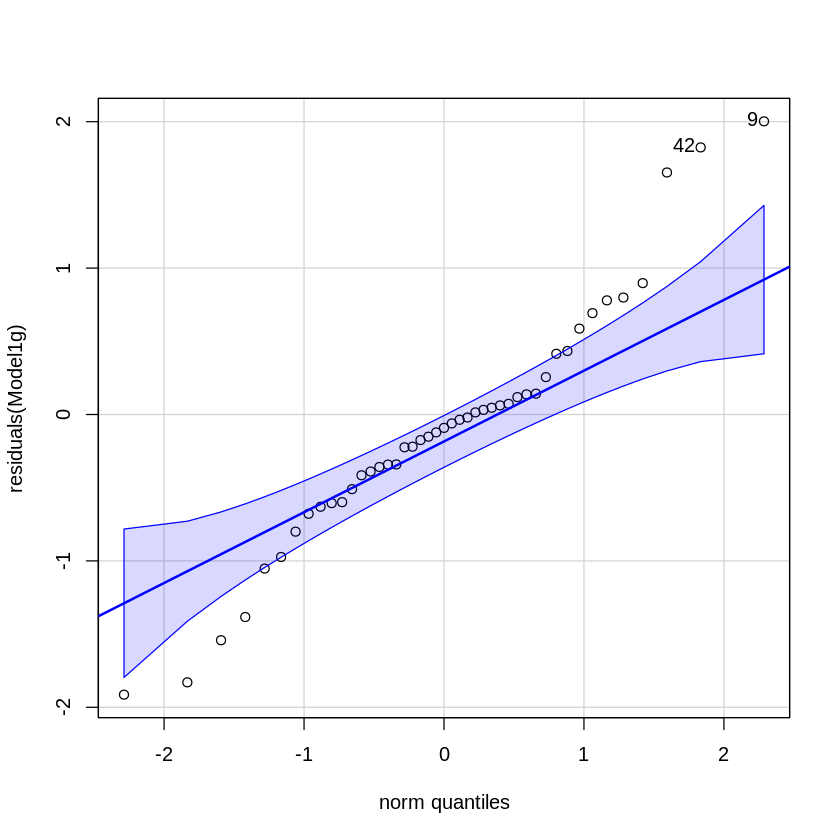

In [127]:
qqPlot(residuals(Model1g))

__Shapiro-Wilk Test__

In [128]:
shapiro.test(residuals(Model1g))


	Shapiro-Wilk normality test

data:  residuals(Model1g)
W = 0.95824, p-value = 0.1047


still some indications of deviation from normality with longer tails then expected. Let use DHAMRa again to get more details.

__DHARMa Residual Diagnostics__

Object of Class DHARMa with simulated residuals based on 250 simulations with refit = FALSE . See ?DHARMa::simulateResiduals for help. 
 
Scaled residual values: 0.691215 0.2400525 0.5429373 0.7768445 0.4343435 0.5378161 0.4989542 0.3878303 0.9900129 0.3595722 0.6788515 0.6362918 0.6554261 0.2837058 0.5297469 0.5966144 0.5642311 0.8332069 0.2678221 0.4216601 ...

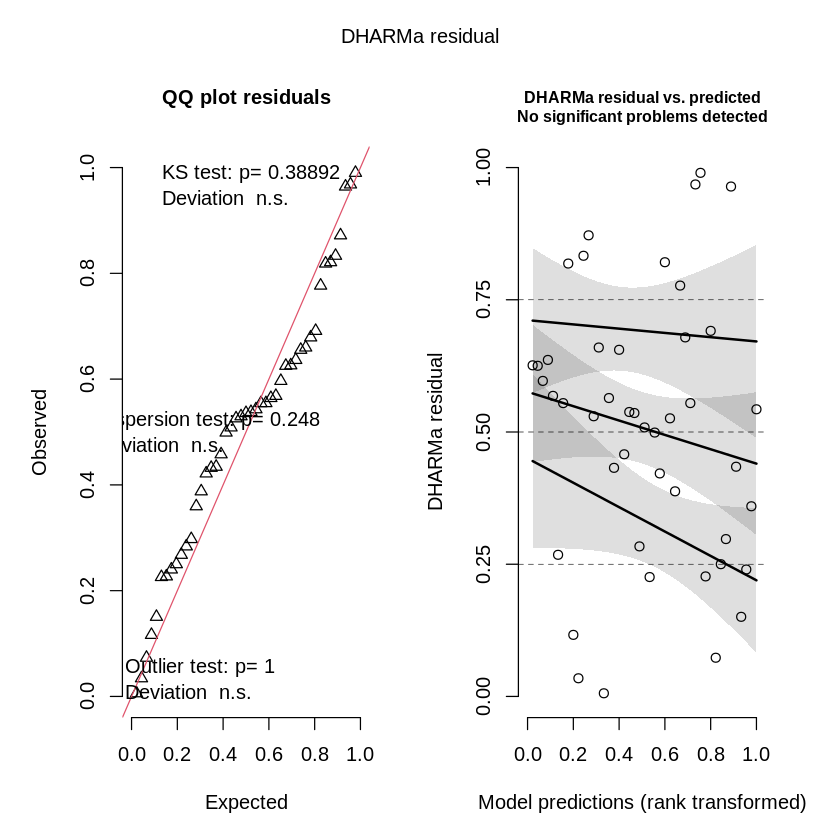

In [129]:
#simulateResiduals(Model1g, plot = TRUE)

DHARMa::simulateResiduals(Model1g, plot = T)

This looks better, but the second plot suggests a non-linear deviation, resembling a hyperbolic pattern. Perhaps a transformation of one explanatory variable could address this?



### Step 12: Fit GLMM with Quadratic Effect

In [130]:
Model4g <- glmer(
  Richness ~ Expos +
    NAP +
    I(NAP^2) +
    NAP:Expos +
    (NAP | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

### Step 13: Diagnostics for Model 4g
__Residual Plot__

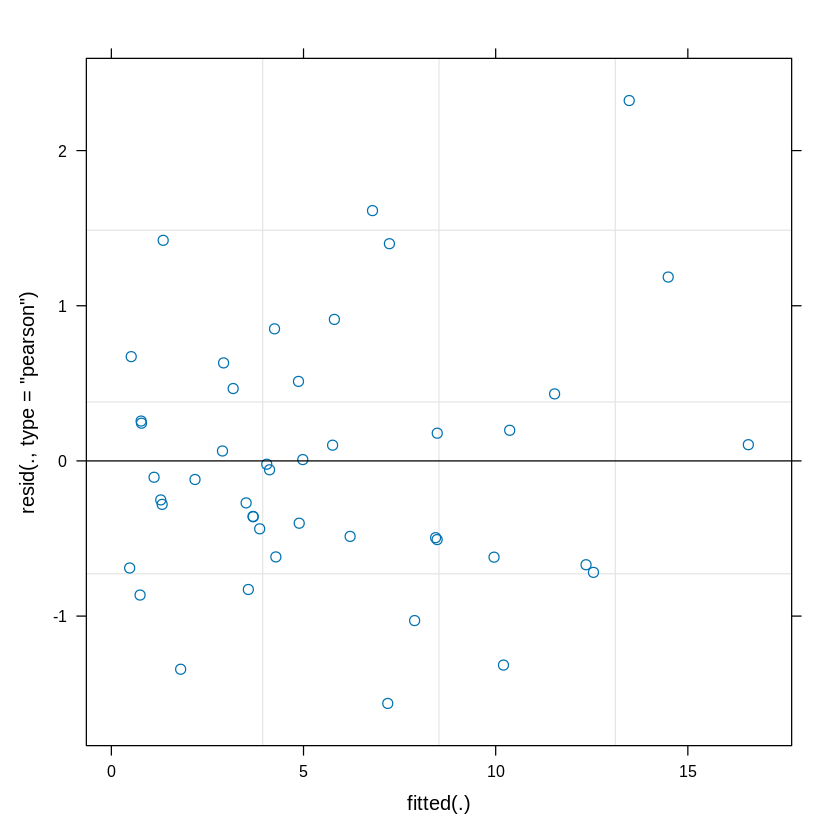

In [131]:
plot(Model4g)

__Q-Q Plot__

[1] 22 24

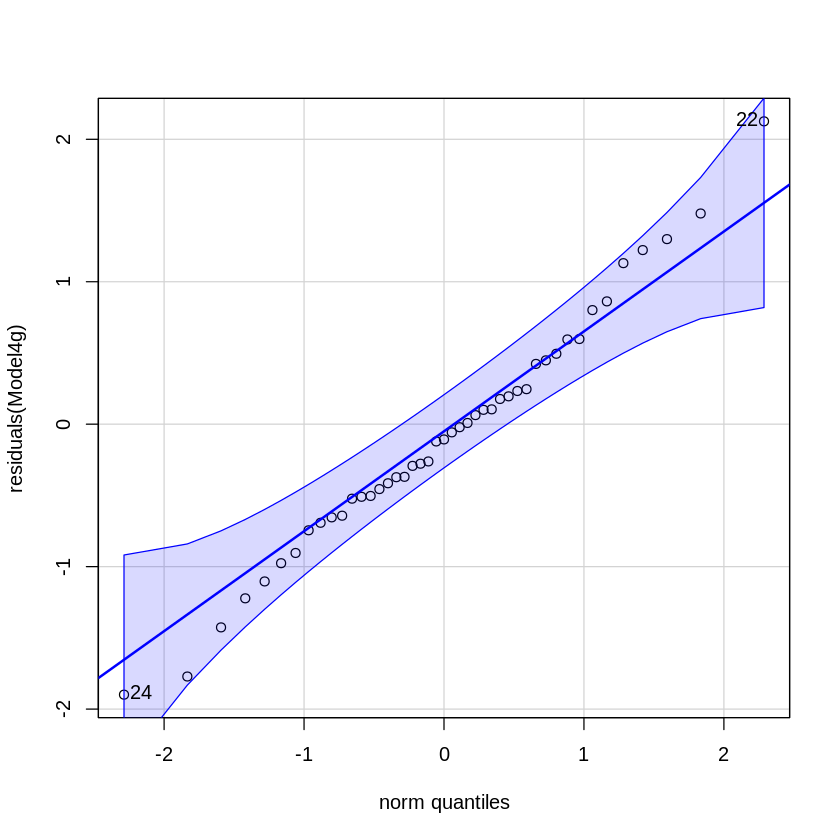

In [132]:
qqPlot(residuals(Model4g))

__Simulated Residuals__

Object of Class DHARMa with simulated residuals based on 250 simulations with refit = FALSE . See ?DHARMa::simulateResiduals for help. 
 
Scaled residual values: 0.5916274 0.2389225 0.6243942 0.9058942 0.2705712 0.7989467 0.5864423 0.3361971 0.9112516 0.555951 0.8362974 0.4976972 0.5935604 0.2625211 0.3382646 0.5691078 0.3083401 0.6740666 0.5403137 0.5452041 ...

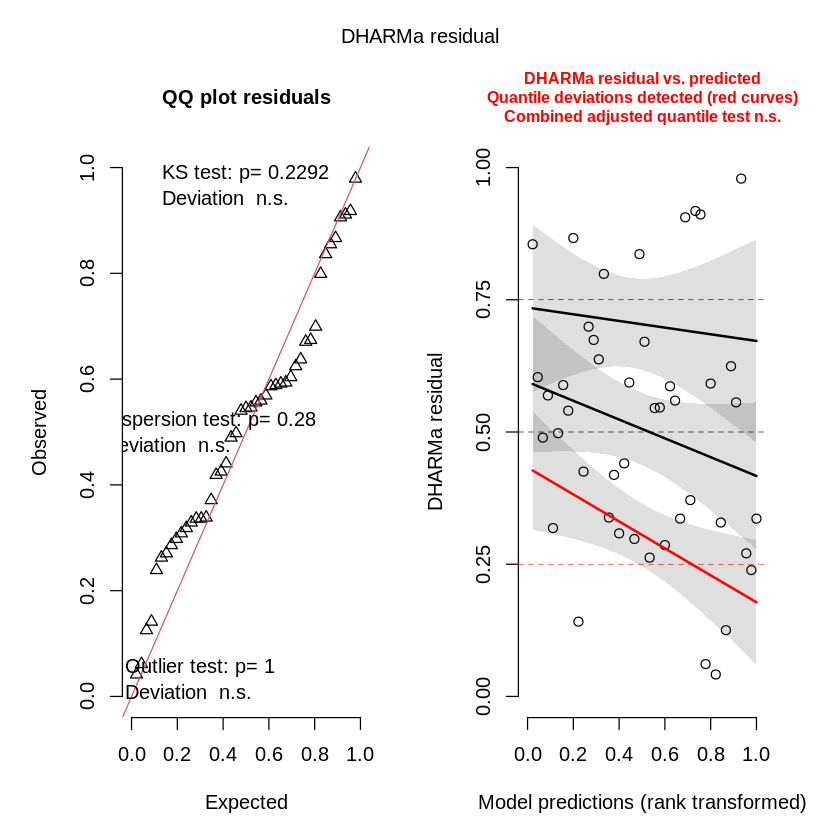

In [133]:
#simulateResiduals(Model4g, plot = TRUE)

DHARMa::simulateResiduals(Model4g, plot = T)

That looks promising no wordings given by DHARMa.

Look at summary

### Step 14: Model Summaries

In [134]:
summary(Model4g)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: Richness ~ Expos + NAP + I(NAP^2) + NAP:Expos + (NAP | Expos:Beaches)
   Data: Rikz

      AIC       BIC    logLik -2*log(L)  df.resid 
    207.7     222.2     -95.9     191.7        37 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.5631 -0.5071 -0.1053  0.4319  2.3226 

Random effects:
 Groups        Name        Variance Std.Dev. Corr 
 Expos:Beaches (Intercept) 0.07715  0.2778        
               NAP         0.01518  0.1232   0.20 
Number of obs: 45, groups:  Expos:Beaches, 9

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   2.2524     0.1575  14.304  < 2e-16 ***
Expos11      -0.9001     0.2436  -3.695  0.00022 ***
NAP          -0.5186     0.1272  -4.077 4.57e-05 ***
I(NAP^2)     -0.2829     0.1072  -2.639  0.00831 ** 
Expos11:NAP   0.1440     0.2305   0.625  0.53223    
---
Signif. codes:  0 ‘***’ 0.001

In [135]:
summary(Model1g)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: Richness ~ Expos + NAP + NAP:Expos + (NAP | Expos:Beaches)
   Data: Rikz

      AIC       BIC    logLik -2*log(L)  df.resid 
    213.1     225.8     -99.6     199.1        38 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.37708 -0.49569 -0.09002  0.14356  2.19048 

Random effects:
 Groups        Name        Variance Std.Dev. Corr 
 Expos:Beaches (Intercept) 0.07098  0.2664        
               NAP         0.08997  0.2999   0.35 
Number of obs: 45, groups:  Expos:Beaches, 9

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.09804    0.14382  14.588  < 2e-16 ***
Expos11     -0.93396    0.23802  -3.924 8.71e-05 ***
NAP         -0.60306    0.17093  -3.528 0.000419 ***
Expos11:NAP  0.01432    0.27740   0.052 0.958828    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixe

Random effects are small but there is clearly some affect in the fixed effect table. Lest investigate the confidence intervals

### Step 15: Confidence Intervals

In [137]:
# confint(Model4g)

                    2.5 %      97.5 %
    .sig01       0.1300737  0.54824427
    .sig02      -1.0000000  1.00000000
    .sig03       0.0000000  0.47360322
    (Intercept)  1.9024228  2.58261777
    Expos11     -1.4180951 -0.37374051
    NAP         -0.8628996 -0.27015646
    I(NAP^2)    -0.4883426 -0.07776457
    Expos11:NAP -0.3486161  0.64678940

and plot the random effets.

### Step 16: Random Effects Plot

$`Expos:Beaches`


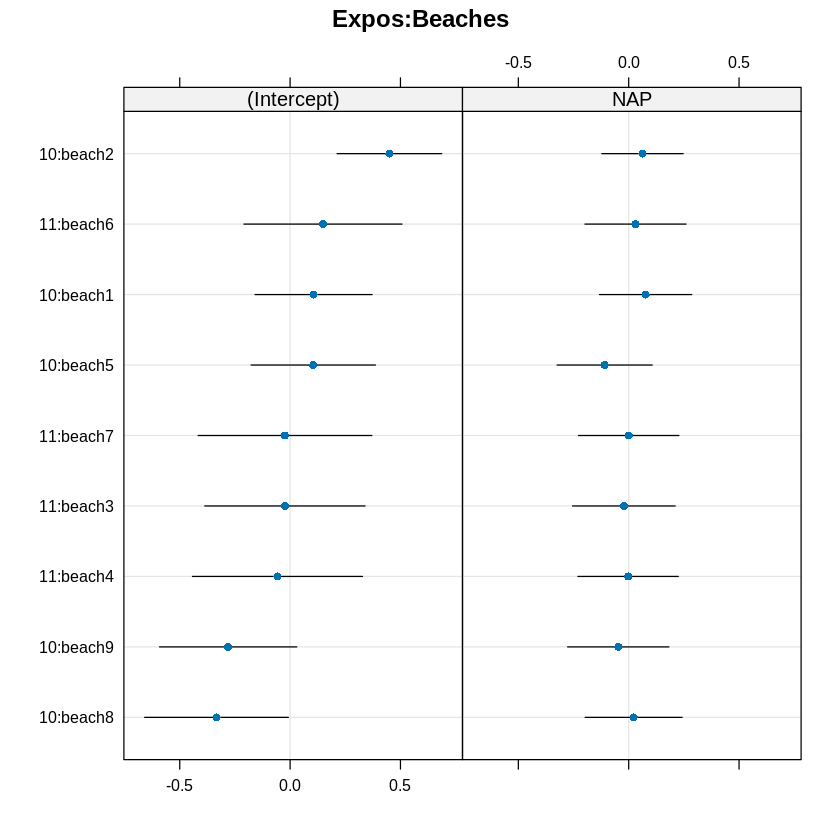

In [138]:
library(lattice)

dotplot(ranef( Model4g, condVar = TRUE))

We could take out the effect the interaction term of the fixed effect.

### Step 17: Reduced GLMM Models
__Model 5g: Remove Interaction__

In [139]:
Model5g <- glmer(Richness ~ Expos + NAP + I(NAP^2) +
    (NAP | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

summary(Model5g)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: Richness ~ Expos + NAP + I(NAP^2) + (NAP | Expos:Beaches)
   Data: Rikz

      AIC       BIC    logLik -2*log(L)  df.resid 
    206.1     218.8     -96.1     192.1        38 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.55810 -0.49752 -0.05726  0.38422  2.33341 

Random effects:
 Groups        Name        Variance Std.Dev. Corr 
 Expos:Beaches (Intercept) 0.07524  0.2743        
               NAP         0.01897  0.1377   0.18 
Number of obs: 45, groups:  Expos:Beaches, 9

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   2.2514     0.1551  14.514  < 2e-16 ***
Expos11      -0.9179     0.2416  -3.799 0.000145 ***
NAP          -0.4857     0.1101  -4.413 1.02e-05 ***
I(NAP^2)     -0.2652     0.1009  -2.628 0.008594 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed

And we could take out the interaction of the random effect on N (slope).

__Model 6g: Random Intercept Only__

In [140]:
Model6g <- glmer(Richness ~ Expos + NAP + I(NAP^2) +
    (1 | Expos:Beaches),
  family = poisson(link = "log"),
  data = Rikz
)

summary(Model6g)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: Richness ~ Expos + NAP + I(NAP^2) + (1 | Expos:Beaches)
   Data: Rikz

      AIC       BIC    logLik -2*log(L)  df.resid 
    202.3     211.4     -96.2     192.3        40 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.5675 -0.5962 -0.1225  0.4158  2.7465 

Random effects:
 Groups        Name        Variance Std.Dev.
 Expos:Beaches (Intercept) 0.07463  0.2732  
Number of obs: 45, groups:  Expos:Beaches, 9

Fixed effects:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.25254    0.15374  14.652  < 2e-16 ***
Expos11     -0.89799    0.23737  -3.783 0.000155 ***
NAP         -0.46537    0.08383  -5.552 2.83e-08 ***
I(NAP^2)    -0.29021    0.08564  -3.389 0.000702 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
         (Intr) Exps11 NAP   
Expos11  -0.577              
NAP  

Compare the last two models.

### Step 18: Compare Final Models
__Akaike Information Criterion__

In [141]:
AIC(Model4g, Model5g, Model6g)

,df,AIC
,<dbl>,<dbl>
Model4g,8,207.7299
Model5g,7,206.1098
Model6g,5,202.3199


__Likelihood Ratio Test__

In [142]:
anova(Model5g, Model6g)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model6g,5,202.3199,211.3532,-96.15996,192.3199,NA,NA,NA
Model5g,7,206.1098,218.7565,-96.05491,192.1098,0.2100937,2,0.9002823


Hence we choose model6g.

No post is needed as Exposure has only two levels.

<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...!

Ms.MRUNALINI (Data Science Trainer)
